# DATA PREPROCESSING 

### Load Dataset

In [26]:
import pandas as pd

df = pd.read_csv("integrated_property_data.csv")
df.head()

,Price,Area_SqFt,Bedrooms,Location,Bathrooms,Source,Price_Per_SqFt
0,208500.0,1710.0,3.0,CollgCr,2.5,Ames_USA,121.929825
1,181500.0,1262.0,3.0,Veenker,2.0,Ames_USA,143.819334
2,223500.0,1786.0,3.0,CollgCr,2.5,Ames_USA,125.139978
3,140000.0,1717.0,3.0,Crawfor,1.0,Ames_USA,81.537566
4,250000.0,2198.0,4.0,NoRidge,2.5,Ames_USA,113.739763


### Understand Data

In [38]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
Index: 1194014 entries, 1693 to 1606835
Data columns (total 7 columns):
 #   Column          Non-Null Count    Dtype  
---  ------          --------------    -----  
 0   Price           1194014 non-null  float64
 1   Area_SqFt       1194014 non-null  float64
 2   Bedrooms        1194014 non-null  float64
 3   Location        1194014 non-null  int64  
 4   Bathrooms       1194014 non-null  float64
 5   Source          1194014 non-null  int64  
 6   Price_Per_SqFt  1194014 non-null  float64
dtypes: float64(5), int64(2)
memory usage: 72.9 MB


,Price,Area_SqFt,Bedrooms,Location,Bathrooms,Source,Price_Per_SqFt
count,1.194014e+06,1.194014e+06,1.194014e+06,1.194014e+06,1.194014e+06,1194014.0,1.194014e+06
mean,3.711436e+05,1.833882e+03,3.179778e+00,8.796998e+03,2.317564e+00,2.0,2.059324e+02
std,2.114769e+05,6.804590e+02,7.934167e-01,5.042103e+03,7.990420e-01,0.0,1.030214e+02
min,0.000000e+00,1.000000e+02,2.000000e+00,0.000000e+00,1.000000e+00,2.0,0.000000e+00
25%,2.150000e+05,1.319000e+03,3.000000e+00,4.396000e+03,2.000000e+00,2.0,1.348857e+02
50%,3.349000e+05,1.713000e+03,3.000000e+00,8.890000e+03,2.000000e+00,2.0,1.857143e+02
75%,4.858988e+05,2.237000e+03,4.000000e+00,1.318300e+04,3.000000e+00,2.0,2.585819e+02
max,1.152900e+06,4.070000e+03,5.000000e+00,1.756300e+04,4.000000e+00,2.0,5.549133e+02


### Check Missing Values

In [39]:
df.isnull().sum()

Price             0
Area_SqFt         0
Bedrooms          0
Location          0
Bathrooms         0
Source            0
Price_Per_SqFt    0
dtype: int64

### Handle Missing Values

In [40]:
#Option 1: Fill values

df.fillna(df.mean(numeric_only=True), inplace=True)

,Price,Area_SqFt,Bedrooms,Location,Bathrooms,Source,Price_Per_SqFt
1693,105000.0,920.0,3.0,63,2.0,2,114.130435
1694,80000.0,1527.0,4.0,63,2.0,2,52.390308
1695,67000.0,748.0,2.0,7672,1.0,2,89.572193
1696,145000.0,1800.0,4.0,12521,2.0,2,80.555556
1697,179000.0,2520.0,4.0,13879,3.0,2,71.031746
...,...,...,...,...,...,...,...
1606830,339900.0,2780.0,4.0,13176,2.0,2,122.266187
1606831,359900.0,3600.0,4.0,13176,2.0,2,99.972222
1606832,350000.0,1616.0,3.0,13176,2.0,2,216.584158
1606834,179900.0,933.0,2.0,13176,1.0,2,192.818864


### Remove Duplicates

In [42]:
df.drop_duplicates(inplace=True)

#Remove repeated data

### Convert Categorical to Numeric

In [43]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.select_dtypes(include=['object', 'string']).columns:
    df[col] = le.fit_transform(df[col])


# Purpose: Machine learning works only with numbers

### Handle Outliers

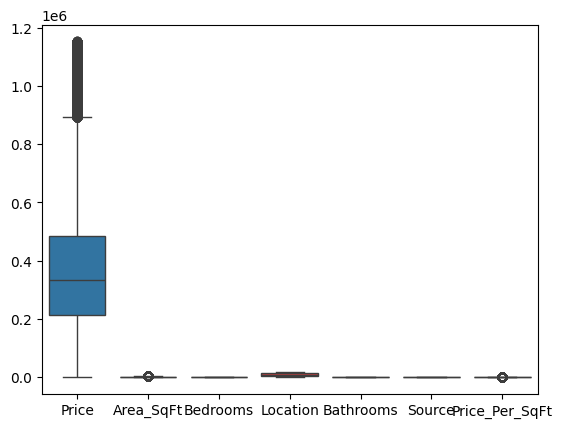

In [44]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(data=df)
plt.show()

Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)

IQR = Q3 - Q1

df = df[~((df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR))).any(axis=1)]

### Correlation Analysis

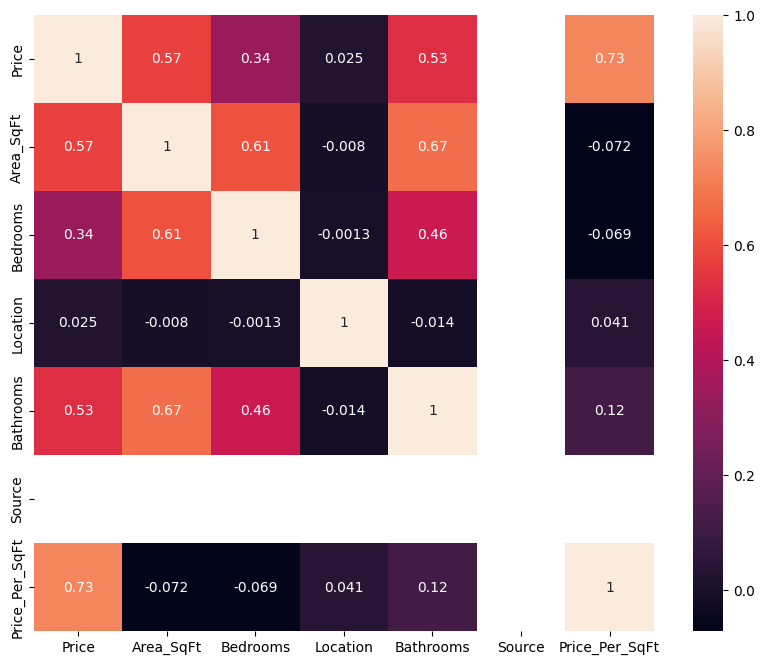

In [45]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True)
plt.show()

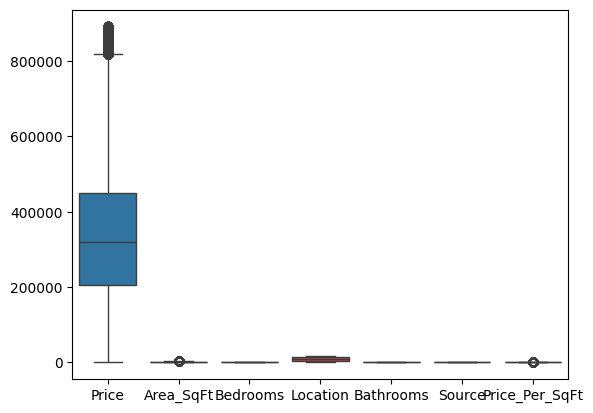

In [46]:
sns.boxplot(data=df)
plt.show()

### Feature Scaling

In [47]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df), columns=df.columns)

In [50]:
df_scaled

,Price,Area_SqFt,Bedrooms,Location,Bathrooms,Source,Price_Per_SqFt
0,0.117684,0.227638,0.333333,0.003587,0.333333,0.0,0.256978
1,0.089664,0.401663,0.666667,0.003587,0.333333,0.0,0.117963
2,0.075094,0.178326,0.000000,0.436827,0.000000,0.0,0.201682
3,0.162516,0.479931,0.666667,0.712919,0.333333,0.0,0.181380
4,0.200624,0.686353,0.666667,0.790241,0.666667,0.0,0.159936
...,...,...,...,...,...,...,...
1112659,0.431509,0.438647,0.666667,0.750214,0.333333,0.0,0.523473
1112660,0.380961,0.760894,0.666667,0.750214,0.333333,0.0,0.275296
1112661,0.403377,0.995986,0.666667,0.750214,0.333333,0.0,0.225099
1112662,0.392281,0.427179,0.333333,0.750214,0.333333,0.0,0.487664


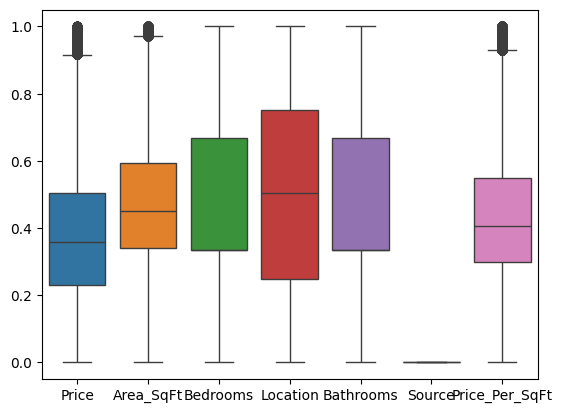

In [51]:
sns.boxplot(data=df_scaled)
plt.show()

### Save Clean Dataset

In [49]:
df_scaled.to_csv("cleaned_real_estate.csv", index=False)